<a href="https://colab.research.google.com/github/RabinPhuyal/Traffic-Sign-Classification-With-Pytorch/blob/main/Traffic_Sign_Classification_With_PyTorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Traffic Sign Classification with PyTorch

A computer vision project for classifying traffic signs using a Convolutional Neural Network (CNN) and the GTSRB dataset.

In [1]:
#Import necesarry libraries
#PyTorch
import torch
from torch import nn
from torch.utils.data import DataLoader

#Torchvision
from torchvision import datasets
from torchvision import transforms

#Data analysis and visualization
import numpy as np
import matplotlib.pyplot as plt

#Randomness
import random

#Checkh PyTorch Version
print(f"PyTorch version: {torch.__version__}")

#Check device
device="cuda" if torch.cuda.is_available() else "cpu"

print(f"Using device: {device}")

PyTorch version: 2.11.0+cu128
Using device: cuda


## 1.Download and Load the GTSRB Dataset

In [2]:
train_data = datasets.GTSRB(
    root="data",
    split="train",
    download=True
)

test_data = datasets.GTSRB(
    root="data",
    split="test",
    download=True
)

100%|██████████| 187M/187M [00:19<00:00, 9.73MB/s]
100%|██████████| 89.0M/89.0M [00:09<00:00, 9.81MB/s]
100%|██████████| 99.6k/99.6k [00:00<00:00, 186kB/s]


In [3]:
#Check the dataset

print(f"Training samples: {len(train_data)}")
print(f"Testing samples: {len(test_data)}")

Training samples: 26640
Testing samples: 12630


In [4]:
'''GTSRB has 43 classes, numbered 0 through 42 and dataitself gives us the
numerical labels, but not a convenient .classes list '''

class_names = [
    "Speed limit 20 km/h",
    "Speed limit 30 km/h",
    "Speed limit 50 km/h",
    "Speed limit 60 km/h",
    "Speed limit 70 km/h",
    "Speed limit 80 km/h",
    "End of speed limit 80 km/h",
    "Speed limit 100 km/h",
    "Speed limit 120 km/h",
    "No passing",
    "No passing for vehicles over 3.5 metric tons",
    "Right-of-way at the next intersection",
    "Priority road",
    "Yield",
    "Stop",
    "No vehicles",
    "Vehicles over 3.5 metric tons prohibited",
    "No entry",
    "General caution",
    "Dangerous curve to the left",
    "Dangerous curve to the right",
    "Double curve",
    "Bumpy road",
    "Slippery road",
    "Road narrows on the right",
    "Road work",
    "Traffic signals",
    "Pedestrians",
    "Children crossing",
    "Bicycles crossing",
    "Beware of ice/snow",
    "Wild animals crossing",
    "End of all speed and passing limits",
    "Turn right ahead",
    "Turn left ahead",
    "Ahead only",
    "Go straight or right",
    "Go straight or left",
    "Keep right",
    "Keep left",
    "Roundabout mandatory",
    "End of no passing",
    "End of no passing by vehicles over 3.5 metric tons"
]

print(f"Number of classes: {len(class_names)}")

Number of classes: 43


In [5]:
#Inspect one image

image,label = train_data[0]

print(f"Image type: {type(image)}")
print(f"Image size: {image.size}")
print(f"Label: {class_names[label]}")

Image type: <class 'PIL.Image.Image'>
Image size: (29, 30)
Label: Speed limit 20 km/h


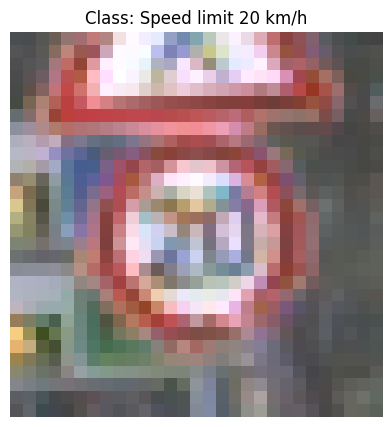

In [6]:
#Visualize our first image

plt.figure(figsize=(5,5))

plt.imshow(image)

plt.title(f"Class: {class_names[label]}")
plt.axis("off")

plt.show()

## 2. Explore the Dataset

In [7]:
random_index = random.randint(0,len(train_data)-1)

image,label = train_data[random_index]

print(f"Random index: {random_index}")
print(f"Image size: {image.size}")
print(f"Label: {label}")
print(f"Class: {class_names[label]}")

Random index: 21381
Image size: (60, 58)
Label: 29
Class: Bicycles crossing


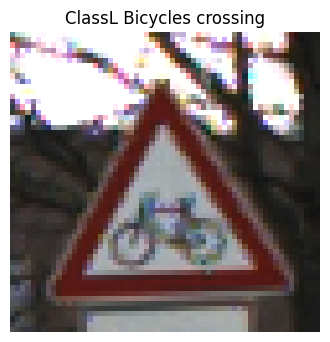

In [8]:
#Display the image
plt.figure(figsize=(4,4))

plt.imshow(image)

plt.title(f"Class: {class_names[label]}")
plt.axis("off")

plt.show()

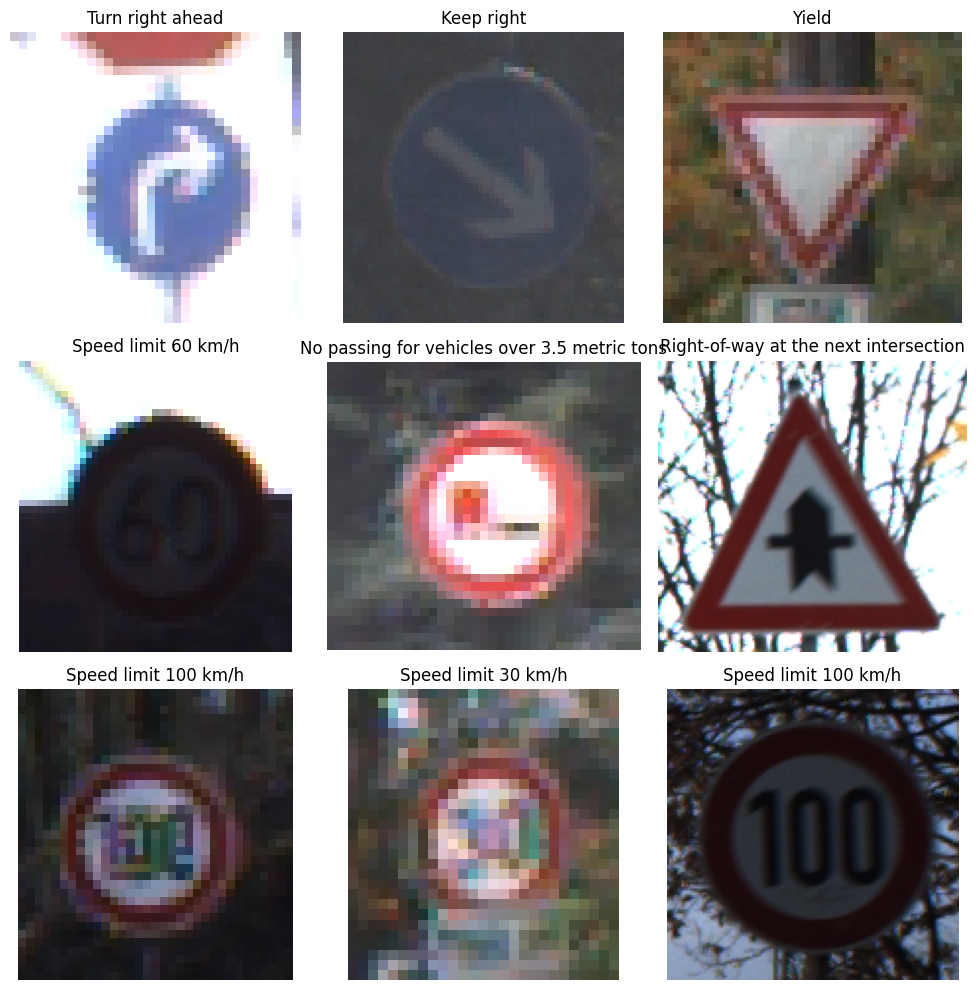

In [9]:
#Display 9 random images

plt.figure(figsize=(10,10))

for i in range(9):
  random_index= random.randint(0,len(train_data)-1)

  image, label = train_data[random_index]

  plt.subplot(3,3,i+1)
  plt.imshow(image)
  plt.title(class_names[label])
  plt.axis("off")

plt.tight_layout()
plt.show()